<a href="https://colab.research.google.com/github/Caory2/Teoria_de_Aprendizaje_de_Maquina/blob/main/TAREA_10_DL_Keras_API_funcional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creación de arquitecturas de aprendizaje profundo mediante API funcional de Keras.

- Se presentan los consideraciones básicas respecto a la [API funcional de Keras](https://keras.io/guides/functional_api/) para la implementación de modelos de redes profundas con TensorFlow.



In [ ]:
import tensorflow as tf #importar tensorflow
print(tf.__version__)

2.18.0


- Se utilizará la base de datos Fashion Mnist nuevamente, normalizando las imágenes de 0 a 1.

In [ ]:
train, test = tf.keras.datasets.fashion_mnist.load_data()
images, labels = train

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- Se presenta un ejemplo de la base de datos

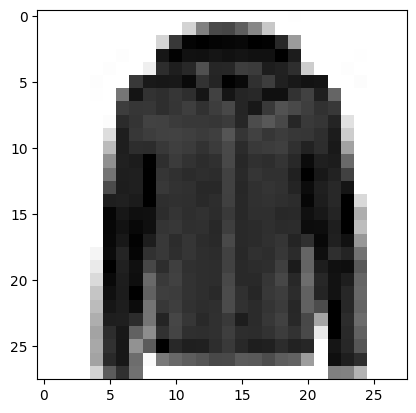

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(images[5000,:,:],cmap= 'binary')
plt.show()

In [ ]:
import numpy as np
print(np.unique(labels)) #etiquetas
print(images.shape) #tamaño de las imágenes

[0 1 2 3 4 5 6 7 8 9]
(60000, 28, 28)


In [ ]:
Xtrain, ytrain = train
Xtrain = Xtrain/255 # tipo flotante, normalizados de 0 a 1
Xtest, ytest = test
Xtest = Xtest/255 # tipo flotante, normalizados de 0 a 1

- En el cuaderno introductorio a redes neuronales con tensorflow se planteó la construcción de modelos mediante secuencia de capas:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-11-10 07:34:28.578802: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ red1 (Dense)                    │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hred2 (Dense)                   │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,560 (654.53 KB)

 Trainable params: 167,560 (654.53 KB)

 Non-trainable params: 0 (0.00 B)

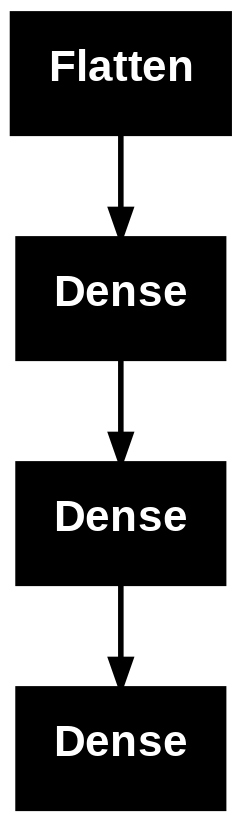

In [ ]:
#definir arquitectura secuencial
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2])),
    tf.keras.layers.Dense(200,activation="relu", name='red1'),
    tf.keras.layers.Dense(50, activation="tanh",name='hred2'),
    tf.keras.layers.Dense(10,activation='softmax',name='output')
])

model.summary() # resumen del modelo
tf.keras.utils.plot_model(model) #diagrama del modelo

- Aunque la implementacióm mediante secuencia es intuitiva, no permite realizar conexiones flexibles entre capas.

- En ese sentido, Keras permite crear capas bajo el principio de funciones y argumentos, como se muestra a continuación.

**Nota**: a diferencia de la estructura secuencial, en la API funcional se debe indicar la capa o capas de entrada y la capa o capas de salida para crear el grafo computacional de forma apropiada.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h1 (Dense)                      │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,560 (654.53 KB)

 Trainable params: 167,560 (654.53 KB)

 Non-trainable params: 0 (0.00 B)

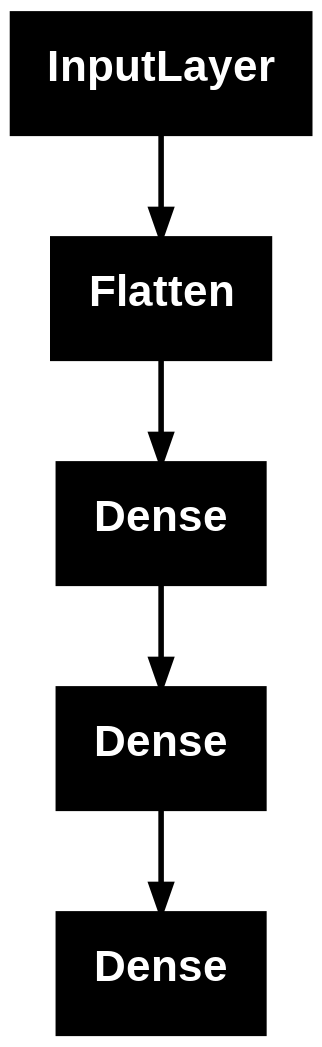

In [ ]:
#arquitectura funcional
#capa de entrada
input_l = tf.keras.layers.Input(shape=(Xtrain.shape[1],Xtrain.shape[2]), name='entrada')
#capa de aplanamiento de las imágenes
flatten = tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2]))(input_l)#argumento de entrada
#capas densas
h1 = tf.keras.layers.Dense(200,activation='tanh',name='h1')(flatten)#argumento de entrada
h2 = tf.keras.layers.Dense(50,activation='tanh',name='h2')(h1)
#capa de salida
output = tf.keras.layers.Dense(10,activation="softmax",name='output')(h2)
#crear modelo según conexiones tipo funcionales
model_fun = tf.keras.Model(inputs=input_l,outputs=output)

#resumen y gráfica del modelo
model_fun.summary()
tf.keras.utils.plot_model(model_fun)


# La API funcional permite realizar conexiones más flexibles

- En el siguiente ejemplo se crea un modelo con una entrada y dos salidas con interconexiones flexibles:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


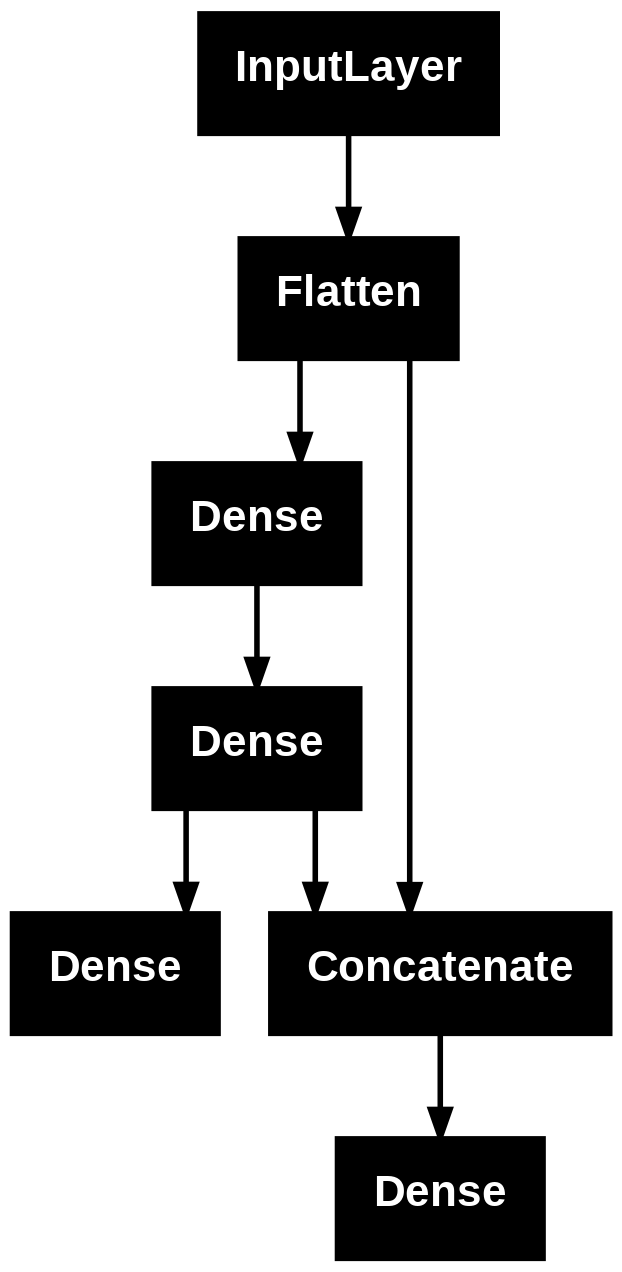

In [ ]:
#arquitectura funcional 2
tf.keras.backend.clear_session()
input_l = tf.keras.layers.Input(shape=(Xtrain.shape[1],Xtrain.shape[2]), name='entrada')
flatten = tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2]))(input_l)

h1 = tf.keras.layers.Dense(200,activation='tanh',name='h1')(flatten)
h2 = tf.keras.layers.Dense(50,activation='tanh',name='h2')(h1)
#capa que concatena caracterísitacas extraídas en h2 con imágenes de entrada
concat = tf.keras.layers.concatenate([h2,flatten])
#se crean dos salidas:
output_A = tf.keras.layers.Dense(10,activation="softmax",name='outputA')(concat)#desde concatenación
output_B = tf.keras.layers.Dense(10,activation="softmax",name='outputB')(h2)#desde h2
#las entradas y salidas se ingresan como listas
model_fun = tf.keras.Model(inputs=input_l,outputs=[output_A, output_B])
#model_fun.summary()
tf.keras.utils.plot_model(model_fun)

**Nota**: si se cuenta con varias salidas se puede definir un mismo costo para cada salida, o una lista con los costos requeridos. Además, en la lista `loss_weights` se puede especificar el valor del peso asociado al costo de cada salida en el intervalo [0,1].

In [ ]:
model_fun.compile(loss="sparse_categorical_crossentropy", #custom_loss(),#custom_loss(),#"sparse_categorical_crossentropy",
              optimizer="Adam",
              metrics=["accuracy","accuracy"]) #f1, precision, recall, crossentropy


- El entrenamiento se realiza de igual forma al utilizado con el modelo secuencial.

- Como se fijaron dos salidas, se debe ingresar una lista para los argumentos ytrain.

In [ ]:
history = model_fun.fit(Xtrain, [ytrain,ytrain] , epochs=10,batch_size=64, # 32, 64, 128, 256
                    validation_split=0.3) # se fija el conjunto de validación como el 20% del de train

Epoch 1/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.4881 - outputA_accuracy: 0.7294 - outputA_loss: 0.8017 - outputB_accuracy: 0.7604 - outputB_loss: 0.6865 - val_loss: 0.8568 - val_outputA_accuracy: 0.8429 - val_outputA_loss: 0.4321 - val_outputB_accuracy: 0.8435 - val_outputB_loss: 0.4242
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.7909 - outputA_accuracy: 0.8552 - outputA_loss: 0.4003 - outputB_accuracy: 0.8580 - outputB_loss: 0.3906 - val_loss: 0.7788 - val_outputA_accuracy: 0.8567 - val_outputA_loss: 0.4032 - val_outputB_accuracy: 0.8644 - val_outputB_loss: 0.3751
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.7213 - outputA_accuracy: 0.8682 - outputA_loss: 0.3661 - outputB_accuracy: 0.8719 - outputB_loss: 0.3552 - val_loss: 0.7318 - val_outputA_accuracy: 0.8679 - val_outputA_loss: 0.3657 - val_outputB_accuracy: 0.8671 - val_outputB_loss: 0.3649
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.6507 - outputA_accuracy: 0.8791 

- Se presentan las curvas de desempeño:

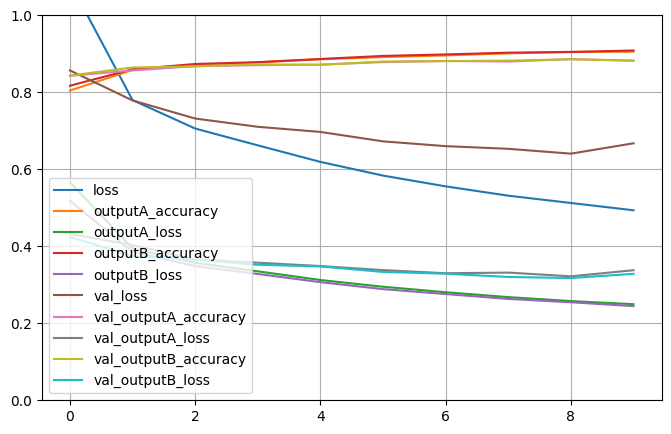

In [ ]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
#save_fig("keras_learning_curves_plot")
plt.show()

- Como el modelo generado presenta dos salidas, el rendimiento se discrimina por cada salida y el acumulado.

- A la hora de predecir la salida para una nueva muestra, se debe tener en cuenta la cantidad de salidas fijadas.

In [ ]:
yestA,yestB = model_fun.predict(Xtest)
print(yestA.shape,yestB.shape)#salidas tipo 1 -K probabilidad de membresia a cada clase

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10) (10000, 10)


In [ ]:
print(yestA[0].argmax(),ytest[0])#para estimar la etiqueta ordinal se encuentra el max por columnas

9 9


In [ ]:
scoreA = model_fun.evaluate(Xtest,[ytest,ytest])#evaluacion
print(scoreA)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7401 - outputA_accuracy: 0.8732 - outputA_loss: 0.3729 - outputB_accuracy: 0.8723 - outputB_loss: 0.3672
[0.7430299520492554, 0.37541359663009644, 0.36703282594680786, 0.8716999888420105, 0.8736000061035156]


# Grafiquemos los pesos respecto a las dimensiones de la imagen original

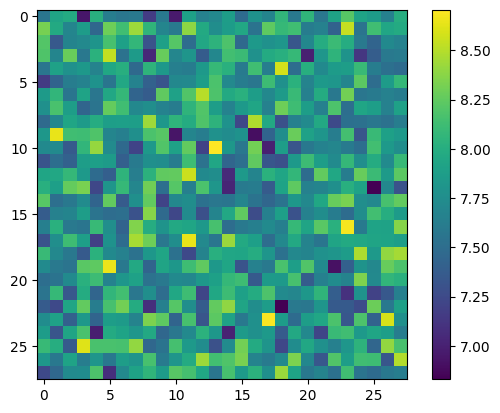

In [ ]:
#se busca identificar las entradas más relevantes para la red
plt.imshow(abs(model.layers[1].get_weights()[0]).sum(axis=1).reshape(28,28))
plt.colorbar()
plt.show()

In [ ]:
model.layers[1].get_weights()[1].shape # accediendo a los bias

(200,)

# Salidas parciales de la red

- La estrategia funcional nos permite acceder a partes intermedias de la red para encontrar mapas de características y verificar el aprendizaje de la representación.

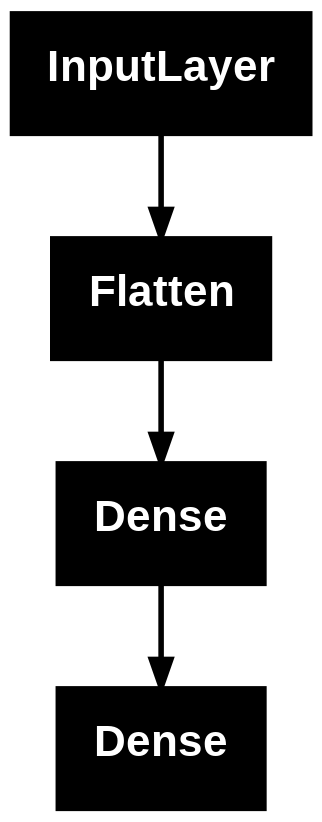

In [ ]:
#crear nuevo modelo con salida parcial
model_B = tf.keras.Model(inputs=model_fun.inputs,outputs=model_fun.get_layer('h2').output) #se accede a capas por nombre
tf.keras.utils.plot_model(model_B) # modelo ya esta ajustado!


In [ ]:
z = model_B.predict(Xtest) # salida en h2
z.shape

121/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['entrada']
Received: inputs=Tensor(shape=(32, 28, 28))
  warnings.warn(msg)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['entrada']
Received: inputs=Tensor(shape=(None, 28, 28))
  warnings.warn(msg)


(10000, 50)

### Dado que se fijaron 50 unidades, se pueden utilizar técnicas de reducción de dimensión para visualizar los patrones intermedios de la red en 2D.


# Principal Component Analysis (PCA)

Reducción de dimensión lineal basado en la preservación de la varianza

![PCA1](https://www.soloentendidos.com/wp-content/uploads/2021/06/Principal-Component-Analysis-second-principal_thumb-1.gif)


![PCA2](https://1.bp.blogspot.com/-pgMAHiIWvuw/Tql5HIXNdRI/AAAAAAAABLI/I2zPF5cLRwQ/s1600/clust.gif)


# t-student distributed Stochastic Neighbor Embedding (t-SNE)

Reducción de dimensión basado en la preservación de localidades (vecinos) utilizando medidas de información desde estimación no paramétrica de probabilidad en el espación de alta y baja dimensión, respectivamente.

![tsne](https://learnopencv.com/wp-content/uploads/2022/11/tsne.gif)

![tsne2](https://3.bp.blogspot.com/-NE01azL_JxU/Wxli17oYNzI/AAAAAAAACxQ/axOI2yy-Ft0QbqaekOyemm5Xn0wAFvRUwCLcBGAs/s640/image2.gif)

In [ ]:
from sklearn.decomposition import PCA
zpca = PCA(n_components=2).fit_transform(z)
zpca.shape

(10000, 2)

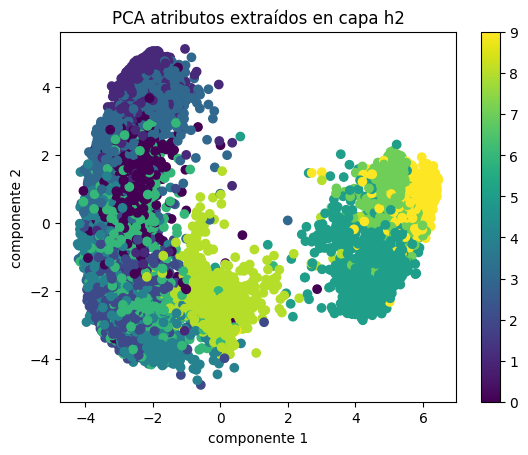

In [ ]:
plt.scatter(zpca[:,0],zpca[:,1],c=ytest)
plt.colorbar()
plt.xlabel('componente 1')
plt.ylabel('componente 2')
plt.title('PCA atributos extraídos en capa h2')
plt.show()

In [ ]:
#plot mnist 2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
def plot_mnist_2d(Z,y,images,img_w=28,img_h=28,zoom=0.5,cmap='jet'):
    fig, ax = plt.subplots(figsize=(16,10))
    for i in range(Z.shape[0]):
        #print('img',i+1,'/',Z.shape[0])
        image = images[i].reshape((img_w, img_h))
        im = OffsetImage(image, zoom=zoom,cmap=cmap)
        ab = AnnotationBbox(im, (Z[i,0], Z[i,1]), xycoords='data', frameon=False)
        ax.add_artist(ab)
        ax.update_datalim([(Z[i,0], Z[i,1])])
        ax.autoscale()

- También, podemos revisar la distribución de las imágenes en el espacio proyectado:

Text(0.5, 1.0, 'PCA atributos extraídos en capa h2')

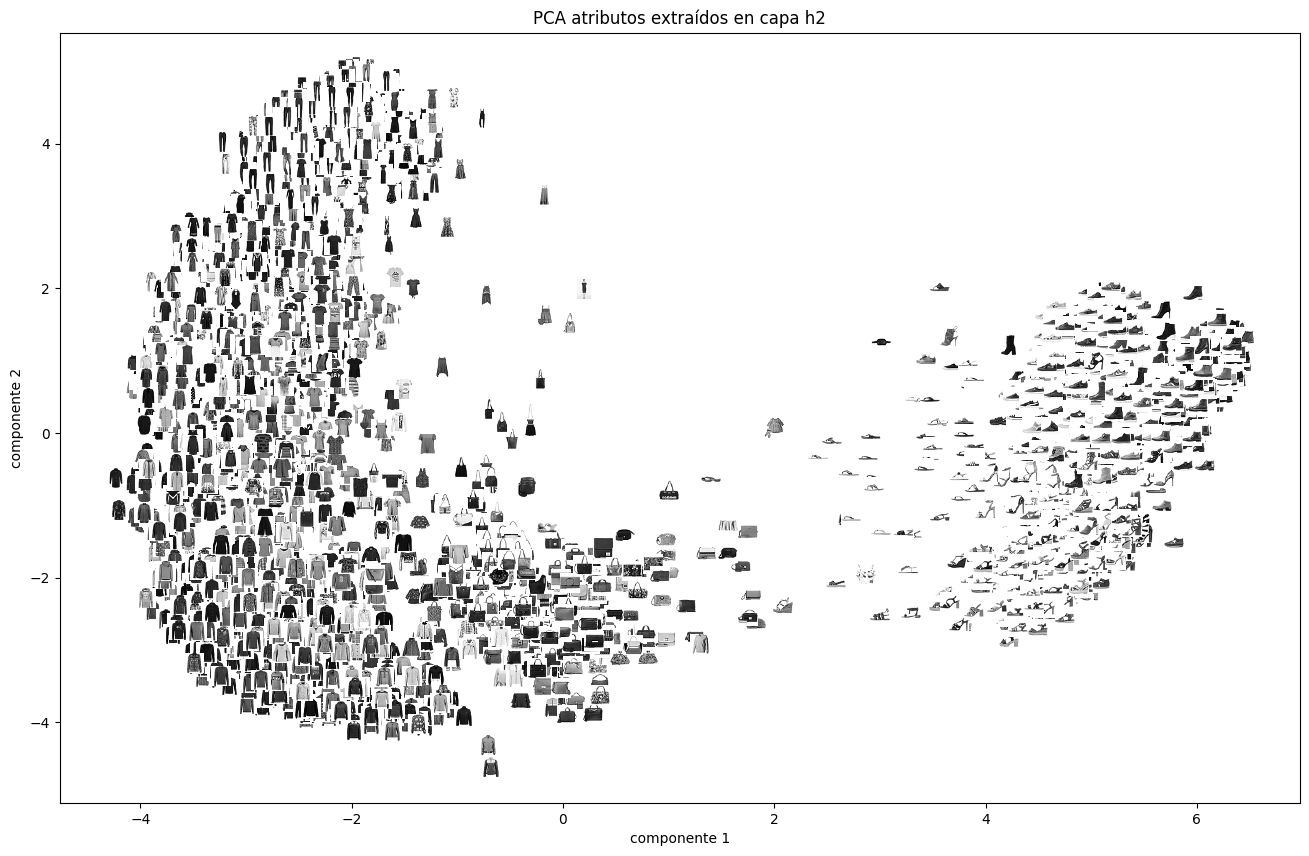

In [ ]:
Ni =4000 # graficar Ni muestras como imagenes en espacio 2D
ind = np.random.randint(0,ytest.shape[0],Ni)
plot_mnist_2d(zpca[ind],ytest[ind],Xtest[ind],img_w=28,img_h=28,zoom=0.5,cmap='binary')
plt.xlabel('componente 1')
plt.ylabel('componente 2')
plt.title('PCA atributos extraídos en capa h2')

# Ejercicio:

- Grafique el espacio proyectado de PCA en 2D (etiquetas e imágenes) para los atributos aprendidos por la capa de concatenación.

- Repita el proceso aplicando la técnica de reducción de dimensión [UMAP de RAPIDS](https://developer.nvidia.com/blog/even-faster-and-more-scalable-umap-on-the-gpu-with-rapids-cuml/).

- Plantee una nueva arquitectura tipo funcional utilizando capas convolucionales (Ver cuaderno [CNNs](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/3_Introduccion_CNN.ipynb)) para el entrenamiento de la base de datos Mnist-digitos, utilizando tres entradas: i) imágenes limpias, ii) y iii) imágenes con ruido blanco Gaussiano ante diferentes varianzas, y dos salidas i) estimación del digito, ii) estimación número par número impar.

In [ ]:

import tensorflow as tf #importar tensorflow
print(tf.__version__)

In [ ]:
train, test = tf.keras.datasets.fashion_mnist.load_data()
images, labels = train

In [ ]:
#Ayuda de código:
#cargar fashion mnist o mnist
#(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train, X_valid = X_train[:-55000], X_train[-55000:]
y_train, y_valid = y_train[:-55000], y_train[-55000:]

X_train = X_train[..., np.newaxis]/255.
X_valid = X_valid[..., np.newaxis]/255.
X_test = X_test[..., np.newaxis]/255.
print(X_train.shape,X_valid.shape,X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


NameError: name 'np' is not defined

# **SOLUCION:**
Grafique el espacio proyectado de PCA en 2D (etiquetas e imágenes) para los atributos aprendidos por la capa de concatenación.

Tamaño: (60000, 28, 28, 1) (10000, 28, 28, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 26, 26,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 24,    │        416 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 13, 13,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 12,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 5408)      │          0 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 2304)      │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenacion       │ (None, 7712)      │          0 │ flatten_3[0][0],  │
│ (Concatenate)       │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │     77,130 │ concatenacion[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,866 (304.16 KB)

 Trainable params: 77,866 (304.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.7569 - loss: 0.7240 - val_accuracy: 0.8738 - val_loss: 0.3607
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8773 - loss: 0.3553 - val_accuracy: 0.8777 - val_loss: 0.3471
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8933 - loss: 0.3064 - val_accuracy: 0.8873 - val_loss: 0.3143
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Shape de atributos: (2000, 7712)
Varianza explicada: [0.18591134 0.15561943]


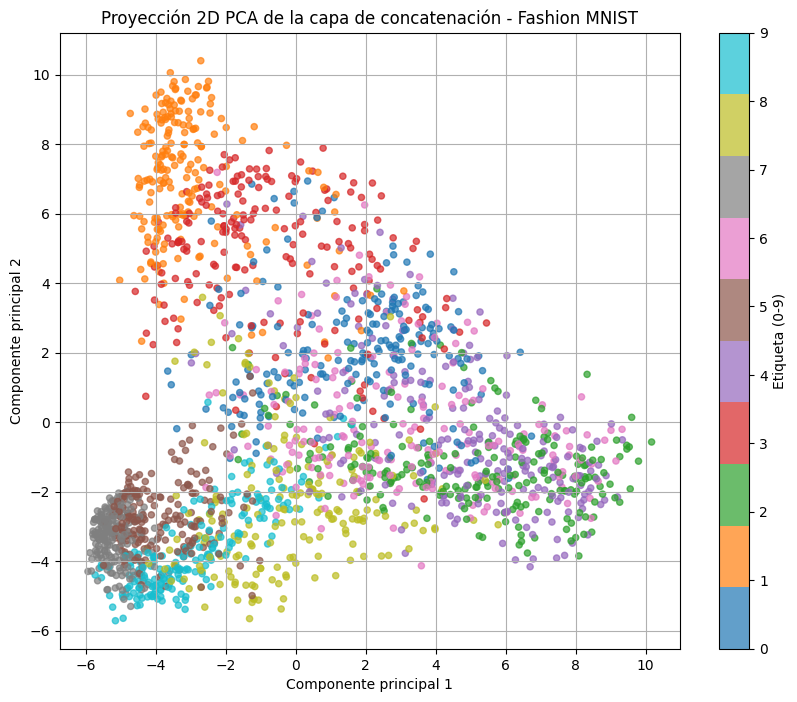

In [ ]:
# ======================================================
# PCA en 2D de los atributos aprendidos por una capa
# de concatenación - Fashion MNIST
# Código compatible con Kaggle
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# ======================================================
# 1. Cargar base de datos
# ======================================================
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalización y reshape
X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

print("Tamaño:", X_train.shape, X_test.shape)

# ======================================================
# 2. Definir un modelo con capa de concatenación
# ======================================================

# Dos ramas convolucionales simples
input_ = keras.Input(shape=(28, 28, 1))

# Rama 1
x1 = layers.Conv2D(32, (3, 3), activation='relu')(input_)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Flatten()(x1)

# Rama 2
x2 = layers.Conv2D(16, (5, 5), activation='relu')(input_)
x2 = layers.MaxPooling2D((2, 2))(x2)
x2 = layers.Flatten()(x2)

# Concatenación
concat = layers.Concatenate(name="concatenacion")([x1, x2])

# Clasificación final
out = layers.Dense(10, activation='softmax')(concat)

# Crear el modelo
model = Model(inputs=input_, outputs=out)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ======================================================
# 3. Entrenar (pocas épocas para ejemplo)
# ======================================================
history = model.fit(X_train, y_train, epochs=3, batch_size=128,
                    validation_split=0.1, verbose=1)

# ======================================================
# 4. Extraer atributos de la capa de concatenación
# ======================================================
feature_extractor = Model(inputs=model.input,
                          outputs=model.get_layer("concatenacion").output)

# Tomamos una muestra del conjunto de prueba (p.ej. 2000 imágenes)
n_samples = 2000
X_subset = X_test[:n_samples]
y_subset = y_test[:n_samples]

features = feature_extractor.predict(X_subset)

print("Shape de atributos:", features.shape)

# ======================================================
# 5. Aplicar PCA a 2D
# ======================================================
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

print("Varianza explicada:", pca.explained_variance_ratio_)

# ======================================================
# 6. Graficar el espacio proyectado
# ======================================================
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0],
                      features_2d[:, 1],
                      c=y_subset,
                      cmap='tab10',
                      alpha=0.7,
                      s=20)

plt.colorbar(scatter, ticks=range(10), label='Etiqueta (0-9)')
plt.title("Proyección 2D PCA de la capa de concatenación - Fashion MNIST")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()


# **SOLUCION:**
Repita el proceso aplicando la técnica de reducción de dimensión UMAP de RAPIDS.


Tamaño: (60000, 28, 28, 1) (10000, 28, 28, 1)


I0000 00:00:1762761288.756252      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762761288.756994      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 26, 26,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 24,    │        416 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 13, 13,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 12,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 5408)      │          0 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2304)      │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenacion       │ (None, 7712)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │     77,130 │ concatenacion[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,866 (304.16 KB)

...

Epoch 1/3


I0000 00:00:1762761291.589575     124 service.cc:148] XLA service 0x79cf980058d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762761291.589923     124 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762761291.589945     124 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762761291.798881     124 cuda_dnn.cc:529] Loaded cuDNN version 90300


 46/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5396 - loss: 1.4370

I0000 00:00:1762761293.540819     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7572 - loss: 0.7199 - val_accuracy: 0.8723 - val_loss: 0.3580
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8815 - loss: 0.3465 - val_accuracy: 0.8937 - val_loss: 0.3104
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8944 - loss: 0.2996 - val_accuracy: 0.8958 - val_loss: 0.2912
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Shape de atributos extraídos: (2000, 7712)


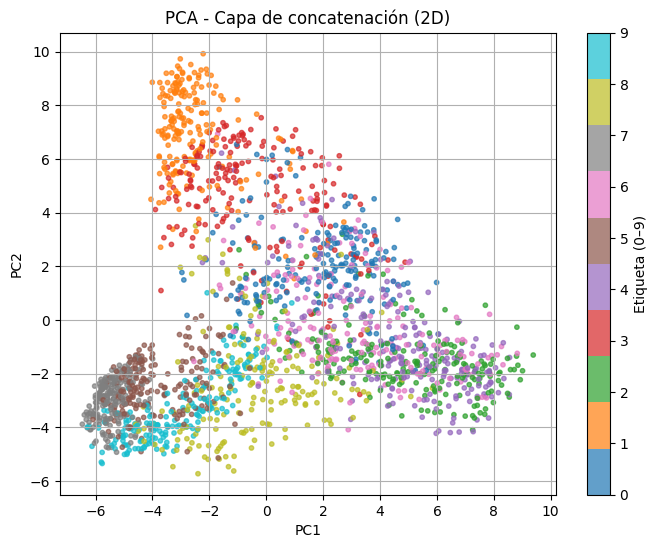

[2025-11-10 07:55:05.772] [CUML] [info] build_algo set to brute_force_knn because random_state is given


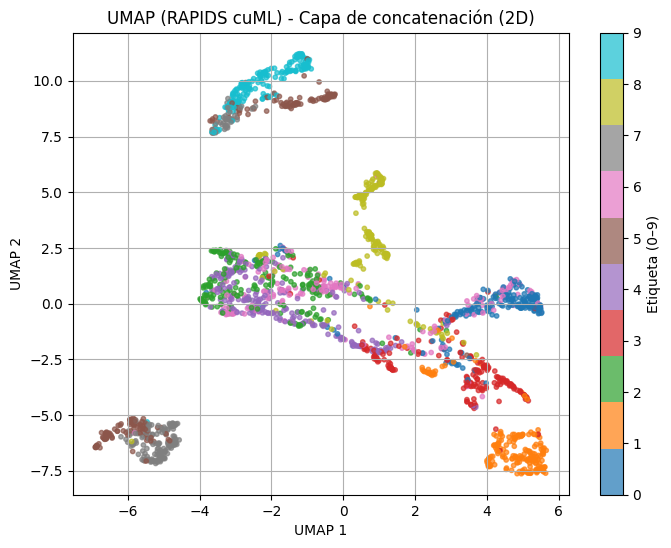

In [ ]:
# ======================================================
# 1. Importar librerías
# ======================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# ======================================================
# 2. Cargar dataset Fashion MNIST
# ======================================================
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

print("Tamaño:", X_train.shape, X_test.shape)

# ======================================================
# 3. Definir modelo con capa de concatenación
# ======================================================
input_ = keras.Input(shape=(28, 28, 1))

# Rama 1
x1 = layers.Conv2D(32, (3, 3), activation='relu')(input_)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Flatten()(x1)

# Rama 2
x2 = layers.Conv2D(16, (5, 5), activation='relu')(input_)
x2 = layers.MaxPooling2D((2, 2))(x2)
x2 = layers.Flatten()(x2)

# Concatenación
concat = layers.Concatenate(name="concatenacion")([x1, x2])

# Salida final
out = layers.Dense(10, activation='softmax')(concat)
model = Model(inputs=input_, outputs=out)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ======================================================
# 4. Entrenar modelo (pocas épocas para demo)
# ======================================================
history = model.fit(X_train, y_train,
                    epochs=3, batch_size=128,
                    validation_split=0.1, verbose=1)

# ======================================================
# 5. Extraer características (features) de la capa de concatenación
# ======================================================
feature_extractor = Model(inputs=model.input,
                          outputs=model.get_layer("concatenacion").output)

# Tomamos una muestra de prueba
n_samples = 2000
X_subset = X_test[:n_samples]
y_subset = y_test[:n_samples]

features = feature_extractor.predict(X_subset)
print("Shape de atributos extraídos:", features.shape)

# ======================================================
# 6. PCA para referencia
# ======================================================
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(features_pca[:,0], features_pca[:,1], c=y_subset, cmap='tab10', s=10, alpha=0.7)
plt.title("PCA - Capa de concatenación (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Etiqueta (0–9)")
plt.grid(True)
plt.show()

# ======================================================
# 7. UMAP con RAPIDS cuML (GPU)
# ======================================================
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q

import cupy as cp
from cuml.manifold import UMAP

# Pasar las features a GPU
features_gpu = cp.asarray(features)

umap = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding_gpu = umap.fit_transform(features_gpu)
embedding = cp.asnumpy(embedding_gpu)

# ======================================================
# 8. Visualización UMAP
# ======================================================
plt.figure(figsize=(8,6))
plt.scatter(embedding[:,0], embedding[:,1], c=y_subset, cmap='tab10', s=10, alpha=0.7)
plt.title("UMAP (RAPIDS cuML) - Capa de concatenación (2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Etiqueta (0–9)")
plt.grid(True)
plt.show()


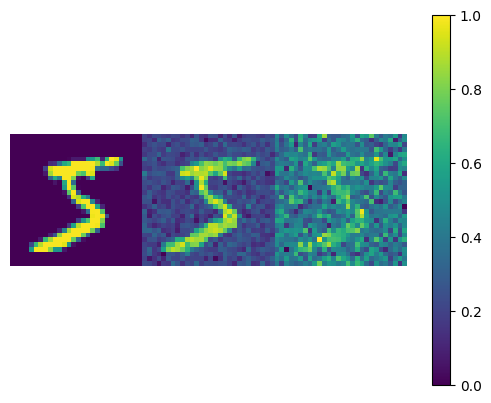

In [ ]:
#crear entradas con y sin ruido
from sklearn.preprocessing import MinMaxScaler

var_ = [0.01,0.25]
inputs_train = [X_train]
inputs_valid = [X_valid]
inputs_test = [X_test]

#recorrer varianzas
for var_i in var_:
    dim = X_train.shape
    #definir ruido
    tmp = X_train + (np.sqrt(var_i)*np.random.randn(X_train.shape[0],dim[1],dim[2],dim[3]))
    tmp = MinMaxScaler().fit_transform(tmp.reshape(dim[0],-1).T).T #fijar señal con ruido de 0 a 1
    inputs_train += [tmp.reshape(dim)]

    dim = X_valid.shape
    tmp = X_valid + (np.sqrt(var_i)*np.random.randn(X_valid.shape[0],dim[1],dim[2],dim[3]))
    tmp = MinMaxScaler().fit_transform(tmp.reshape(dim[0],-1).T).T
    inputs_valid += [tmp.reshape(dim)]

    dim = X_test.shape
    tmp = X_test + (np.sqrt(var_i)*np.random.randn(X_test.shape[0],dim[1],dim[2],dim[3]))
    tmp = MinMaxScaler().fit_transform(tmp.reshape(dim[0],-1).T).T
    inputs_test += [tmp.reshape(dim)]


plt.imshow(np.c_[inputs_train[0][0,:,:,0],inputs_train[1][0,:,:,0],inputs_train[2][0,:,:,0]])
plt.axis('off')
plt.colorbar()
plt.show()

In [ ]:
#veector de salida par o impar
ytrain_B = (y_train % 2)
print(ytrain_B[10:])
print(y_train[10:])

[1 1 1 ... 0 1 0]
[3 5 3 ... 2 1 2]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


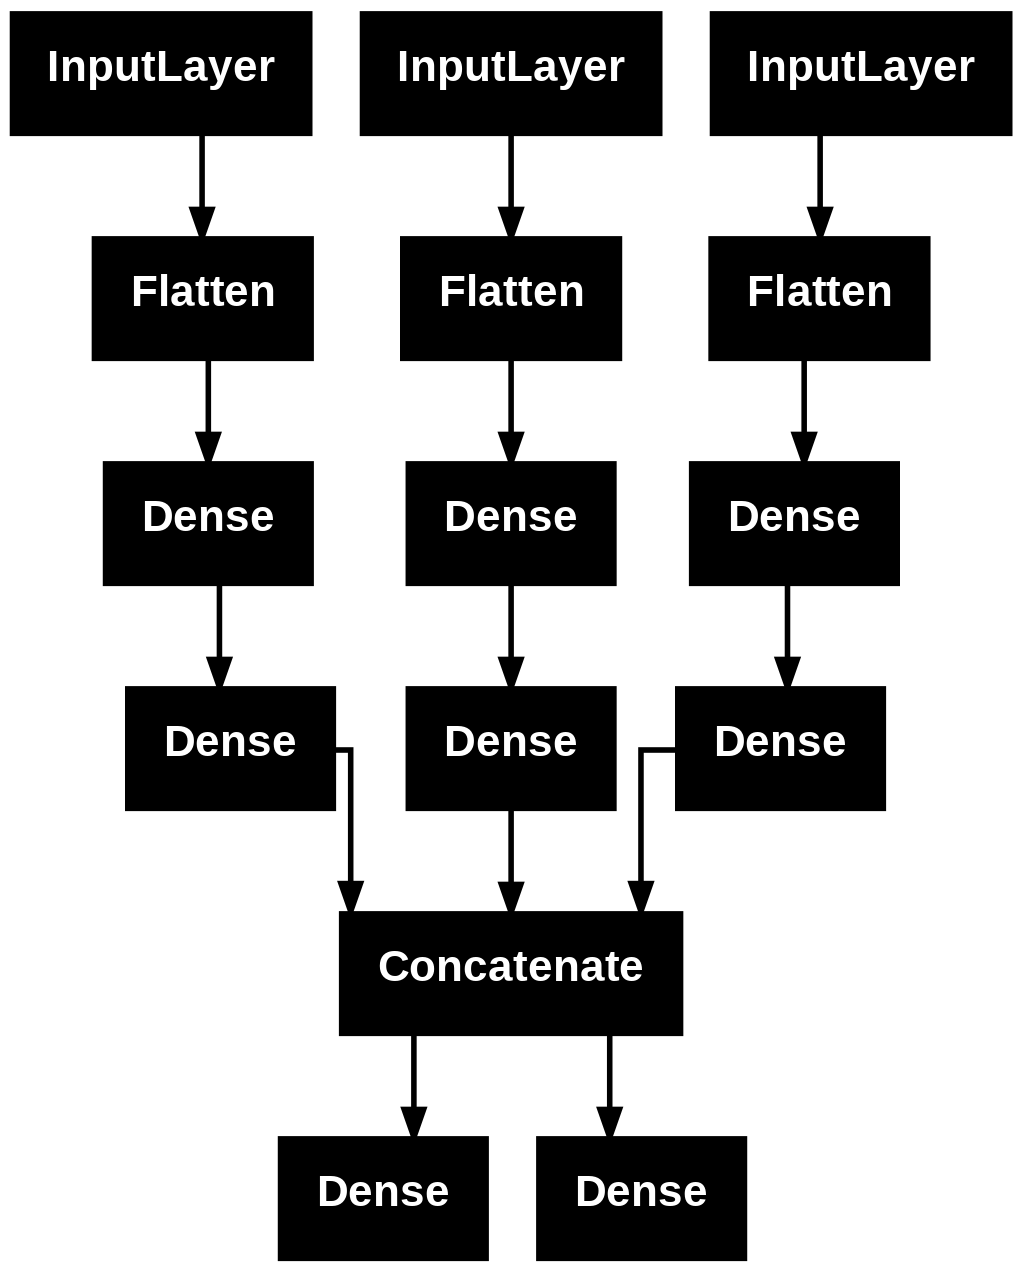

In [ ]:
#arquitectura funcional 2 - Ayuda de código con capas densas - cambiar a capas cnn
tf.keras.backend.clear_session()
input_1 = tf.keras.layers.Input(shape=(Xtrain.shape[1],Xtrain.shape[2]), name='entrada_1')
input_2 = tf.keras.layers.Input(shape=(Xtrain.shape[1],Xtrain.shape[2]), name='entrada_2')
input_3 = tf.keras.layers.Input(shape=(Xtrain.shape[1],Xtrain.shape[2]), name='entrada_3')

flatten_1 = tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2]))(input_1)
flatten_2 = tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2]))(input_2)
flatten_3 = tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2]))(input_3)

h1_1 = tf.keras.layers.Dense(200,activation='tanh',name='h1_1')(flatten_1)
h2_1 = tf.keras.layers.Dense(50,activation='tanh',name='h2_1')(h1_1)

h1_2 = tf.keras.layers.Dense(200,activation='tanh',name='h1_2')(flatten_2)
h2_2 = tf.keras.layers.Dense(50,activation='tanh',name='h2_2')(h1_2)

h1_3 = tf.keras.layers.Dense(200,activation='tanh',name='h1_3')(flatten_3)
h2_3 = tf.keras.layers.Dense(50,activation='tanh',name='h2_3')(h1_3)

#capa que concatena caracterísitacas extraídas en h2 con imágenes de entrada
concat = tf.keras.layers.concatenate([h2_1,h2_2,h2_3])
#se crean dos salidas:
output_d = tf.keras.layers.Dense(10,activation="softmax",name='output_d')(concat)#desde concatenación
output_p = tf.keras.layers.Dense(1,activation="sigmoid",name='output_p')(concat)#desde h2
#las entradas y salidas se ingresan como listas
model_fun2 = tf.keras.Model(inputs=[input_1,input_2,input_3],outputs=[output_d, output_p])
#model_fun.summary()
tf.keras.utils.plot_model(model_fun2)

In [ ]:
#Entrenar y ajustar el modelo, revisar rendimientos en cada salida

# **SOLUCION**
Plantee una nueva arquitectura tipo funcional utilizando capas convolucionales (Ver cuaderno CNNs) para el entrenamiento de la base de datos Mnist-digitos, utilizando tres entradas: i) imágenes limpias, ii) y iii) imágenes con ruido blanco Gaussiano ante diferentes varianzas, y dos salidas i) estimación del digito, ii) estimación número par número impar.

2025-11-10 19:32:06.146152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762803126.353459      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762803126.416977      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shapes: (55000, 28, 28, 1) (5000, 28, 28, 1) (10000, 28, 28, 1)


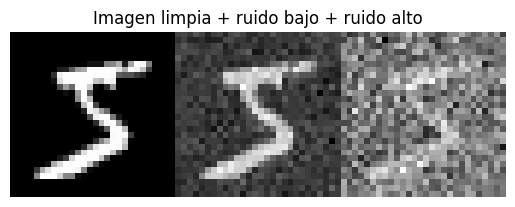

I0000 00:00:1762803149.001971      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762803149.002719      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_1           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_2           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_3           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_1 (Conv2D)    │ (None, 28, 28,    │        320 │ entrada_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1 (Conv2D)    │ (None, 28, 28,    │        320 │ entrada_2[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_1 (Conv2D)    │ (None, 28, 28,    │        320 │ entrada_3[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ conv1_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv3_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_2 (Conv2D)    │ (None, 14, 14,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2 (Conv2D)    │ (None, 14, 14,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_2 (Conv2D)    │ (None, 14, 14,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 64)  │          0 │ conv1_2[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 64)  │          0 │ conv2_2[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ conv3_2[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,262,219 (4.81 MB)

 Trainable params: 1,262,219 (4.81 MB)

...

Epoch 1/5


I0000 00:00:1762803154.542364     110 service.cc:148] XLA service 0x2effe8c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762803154.543294     110 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762803154.543333     110 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762803155.070340     110 cuda_dnn.cc:529] Loaded cuDNN version 90300


 19/430 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.7344 - output_d_accuracy: 0.2633 - output_d_loss: 2.1001 - output_p_accuracy: 0.6292 - output_p_loss: 0.6343

I0000 00:00:1762803158.326647     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


430/430 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.8748 - output_d_accuracy: 0.7977 - output_d_loss: 0.6289 - output_p_accuracy: 0.8878 - output_p_loss: 0.2459 - val_loss: 0.0962 - val_output_d_accuracy: 0.9836 - val_output_d_loss: 0.0555 - val_output_p_accuracy: 0.9868 - val_output_p_loss: 0.0386
Epoch 2/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1440 - output_d_accuracy: 0.9710 - output_d_loss: 0.0981 - output_p_accuracy: 0.9848 - output_p_loss: 0.0459 - val_loss: 0.0697 - val_output_d_accuracy: 0.9884 - val_output_d_loss: 0.0403 - val_output_p_accuracy: 0.9904 - val_output_p_loss: 0.0278
Epoch 3/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0940 - output_d_accuracy: 0.9802 - output_d_loss: 0.0635 - output_p_accuracy: 0.9899 - output_p_loss: 0.0304 - val_loss: 0.0631 - val_output_d_accuracy: 0.9896 - val_output_d_loss: 0.0391 - val_output_p_accuracy: 0.9926 - val_output_p_loss: 0.0226
Epoch 4/5
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0754 - output_d_accu

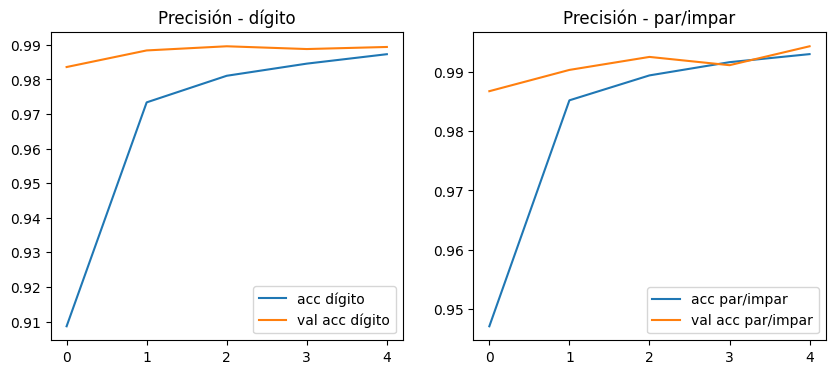

In [ ]:
# ============================================================
# 1. Importar librerías
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 2. Cargar dataset MNIST
# ============================================================
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar y agregar canal
X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

# Dividir para validación
X_valid = X_train[-5000:]
y_valid = y_train[-5000:]
X_train = X_train[:-5000]
y_train = y_train[:-5000]

print("Shapes:", X_train.shape, X_valid.shape, X_test.shape)

# ============================================================
# 3. Crear entradas: sin ruido + con ruido de dos varianzas
# ============================================================
var_ = [0.01, 0.25]
inputs_train = [X_train]
inputs_valid = [X_valid]
inputs_test = [X_test]

for var_i in var_:
    for dataset, target_list in zip([X_train, X_valid, X_test],
                                    [inputs_train, inputs_valid, inputs_test]):
        dim = dataset.shape
        ruido = dataset + np.sqrt(var_i) * np.random.randn(*dim)
        ruido = MinMaxScaler().fit_transform(ruido.reshape(dim[0], -1).T).T
        target_list.append(ruido.reshape(dim))

# Visualizar ejemplo
plt.imshow(np.c_[inputs_train[0][0, :, :, 0],
                 inputs_train[1][0, :, :, 0],
                 inputs_train[2][0, :, :, 0]], cmap='gray')
plt.axis('off')
plt.title("Imagen limpia + ruido bajo + ruido alto")
plt.show()

# ============================================================
# 4. Salida adicional: par o impar
# ============================================================
ytrain_B = (y_train % 2)
yvalid_B = (y_valid % 2)
ytest_B = (y_test % 2)

# ============================================================
# 5. Definir modelo funcional CNN
# ============================================================
tf.keras.backend.clear_session()

# Entradas
input_1 = keras.Input(shape=(28, 28, 1), name="entrada_1")  # limpia
input_2 = keras.Input(shape=(28, 28, 1), name="entrada_2")  # ruido var=0.01
input_3 = keras.Input(shape=(28, 28, 1), name="entrada_3")  # ruido var=0.25

# --- Rama 1 ---
x1 = layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_1')(input_1)
x1 = layers.MaxPooling2D((2,2))(x1)
x1 = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv1_2')(x1)
x1 = layers.MaxPooling2D((2,2))(x1)
x1 = layers.Flatten()(x1)

# --- Rama 2 ---
x2 = layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv2_1')(input_2)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2')(x2)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Flatten()(x2)

# --- Rama 3 ---
x3 = layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv3_1')(input_3)
x3 = layers.MaxPooling2D((2,2))(x3)
x3 = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv3_2')(x3)
x3 = layers.MaxPooling2D((2,2))(x3)
x3 = layers.Flatten()(x3)

# Concatenar características
concat = layers.Concatenate(name="concatenacion")([x1, x2, x3])
dense = layers.Dense(128, activation='relu')(concat)
dense = layers.Dropout(0.3)(dense)

# Dos salidas
output_d = layers.Dense(10, activation="softmax", name="output_d")(dense)
output_p = layers.Dense(1, activation="sigmoid", name="output_p")(dense)

# Crear modelo funcional
model_funCNN = Model(inputs=[input_1, input_2, input_3],
                     outputs=[output_d, output_p])

model_funCNN.summary()

# ============================================================
# 6. Compilación y entrenamiento
# ============================================================
model_funCNN.compile(optimizer='adam',
                     loss={'output_d': 'sparse_categorical_crossentropy',
                           'output_p': 'binary_crossentropy'},
                     metrics={'output_d': 'accuracy',
                              'output_p': 'accuracy'})

history = model_funCNN.fit(
    inputs_train,
    {'output_d': y_train, 'output_p': ytrain_B},
    epochs=5,
    batch_size=128,
    validation_data=(inputs_valid, {'output_d': y_valid, 'output_p': yvalid_B}),
    verbose=1
)

# ============================================================
# 7. Evaluar modelo
# ============================================================
test_results = model_funCNN.evaluate(inputs_test,
                                     {'output_d': y_test, 'output_p': ytest_B})
print("\nResultados de prueba:", test_results)

# ============================================================
# 8. Visualizar resultados
# ============================================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['output_d_accuracy'], label='acc dígito')
plt.plot(history.history['val_output_d_accuracy'], label='val acc dígito')
plt.title('Precisión - dígito')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['output_p_accuracy'], label='acc par/impar')
plt.plot(history.history['val_output_p_accuracy'], label='val acc par/impar')
plt.title('Precisión - par/impar')
plt.legend()
plt.show()
